In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
from collections import Counter
import matplotlib.pyplot as plt

os.chdir('/s1/chengd/project/multiome/01_preprocessing')

kelly = ['#af2337', '#ecc342', '#2967a0', '#2f3c28', '#96b437',
         '#da93ab', '#e58932', '#80598f', '#7e331f', '#3b855a',
         '#c0b286', '#a9c9ed', '#ec977f', '#848482', '#604628',
         '#d26034', '#a64c6b', '#dbd245', '#eba83b', '#5d5092',
         '#222222', '#f2f3f4', '#6a4b93']

mpl.rcParams['axes.prop_cycle'] = plt.cycler(color=kelly)
mpl.rcParams['axes.titlesize'] = 19
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 13
mpl.rcParams['legend.markerscale'] = 2
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['figure.dpi'] = 100
sns.set_style('ticks')

output_dir = '/s1/chengd/project/multiome/02_cellline/qc_figures/04_technical_qc_comparisons'
os.makedirs(output_dir, exist_ok=True)
print(f"输出目录 '{output_dir}' 已准备好。")

输出目录 '/s1/chengd/project/multiome/02_cellline/qc_figures/04_technical_qc_comparisons' 已准备好。


In [2]:

metrics_location = [
    ['DUET-seq'            , 'K562'   , 'atac', './duet-seq/k562/atac/metrics.csv'],
    ['DUET-seq'            , 'K562'   , 'rna' , './duet-seq/k562/rna/metrics.csv'],
    ['ISSAAC-seq (Droplet)', 'K562'   , 'atac', './issaac-seq/k562/atac/metrics.csv'],
    ['ISSAAC-seq (Droplet)', 'K562'   , 'rna' , './issaac-seq/k562/rna/metrics.csv'],
    ['10x Multiome'        , 'K562'   , 'atac', './10x_multiome/k562/atac/metrics.csv'],
    ['10x Multiome'        , 'K562'   , 'rna' , './10x_multiome/k562/rna/metrics.csv'],
    ['SHARE-seq'           , 'K562'   , 'atac', './share-seq/k562/atac/metrics.csv'],
    ['SHARE-seq'           , 'K562'   , 'rna' , './share-seq/k562/rna/metrics.csv'],
    ['SNARE-seq'           , 'K562'   , 'atac', './snare-seq/k562/atac/metrics.csv'],
    ['SNARE-seq'           , 'K562'   , 'rna' , './snare-seq/k562/rna/metrics.csv'],
    ['DUET-seq'            , 'HEK293T', 'atac', './duet-seq/293t/atac/metrics.csv'],
    ['DUET-seq'            , 'HEK293T', 'rna' , './duet-seq/293t/rna/metrics.csv'],
    ['HT-scCAT-seq'        , 'HEK293T', 'atac', './ht-sccat-seq/293t/atac/metrics.csv'],
    ['HT-scCAT-seq'        , 'HEK293T', 'rna' , './ht-sccat-seq/293t/rna/metrics.csv'],
    ['ISSAAC-seq (Droplet)', 'HEK293T', 'atac', './issaac-seq/293t/atac/metrics.csv'],
    ['ISSAAC-seq (Droplet)', 'HEK293T', 'rna' , './issaac-seq/293t/rna/metrics.csv'],
    ['Paired-seq'          , 'HEK293T', 'atac', './paired-seq/293t/atac/metrics.csv'],
    ['Paired-seq'          , 'HEK293T', 'rna' , './paired-seq/293t/rna/metrics.csv'],
    ['sci-CAR-seq'         , 'HEK293T', 'atac', './sci-car-seq/293t/atac/metrics.csv'],
    ['sci-CAR-seq'         , 'HEK293T', 'rna' , './sci-car-seq/293t/rna/metrics.csv'],
    ['DUET-seq'            , 'NIH3T3' , 'atac', './duet-seq/3t3/atac/metrics2.csv'],
    ['DUET-seq'            , 'NIH3T3' , 'rna' , './duet-seq/3t3/rna/metrics.csv'],
    ['SUM-seq'             , 'NIH3T3' , 'atac', './sum-seq/3t3/atac/metrics.csv'],
    ['SUM-seq'             , 'NIH3T3' , 'rna' , './sum-seq/3t3/rna/metrics.csv'],
    ['HT-scCAT-seq'        , 'NIH3T3' , 'atac', './ht-sccat-seq/3t3/atac/metrics.csv'],
    ['HT-scCAT-seq'        , 'NIH3T3' , 'rna' , './ht-sccat-seq/3t3/rna/metrics.csv'],
    ['ISSAAC-seq (Droplet)', 'NIH3T3' , 'atac', './snare2-seq/3t3/atac/metrics.csv'],
    ['ISSAAC-seq (Droplet)', 'NIH3T3' , 'rna' , './snare2-seq/3t3/rna/metrics.csv'],
    ['10x Multiome'        , 'NIH3T3' , 'atac', './10x_multiome/3t3/atac/metrics.csv'],
    ['10x Multiome'        , 'NIH3T3' , 'rna' , './10x_multiome/3t3/rna/metrics.csv'],
    ['SNARE-seq2'          , 'NIH3T3' , 'atac', './snare2-seq/3t3/atac/metrics.csv'],
    ['SNARE-seq2'          , 'NIH3T3' , 'rna' , './snare2-seq/3t3/rna/metrics.csv'],
    ['SHARE-seq'           , 'NIH3T3' , 'atac', './share-seq/3t3/atac/metrics.csv'],
    ['SHARE-seq'           , 'NIH3T3' , 'rna' , './share-seq/3t3/rna/metrics.csv'],
    ['sci-CAR-seq'         , 'NIH3T3' , 'atac', './sci-car-seq/3t3/atac/metrics.csv'],
    ['sci-CAR-seq'         , 'NIH3T3' , 'rna' , './sci-car-seq/3t3/rna/metrics.csv'],
]

In [3]:
dfs = []

for t, c, m, q in metrics_location:
    tmp = pd.read_csv(q)
    tmp['Method'] = t
    tmp['Cell_line'] = c
    tmp['Modality'] = m
    dfs.append(tmp)

cell_lines = pd.concat(dfs, ignore_index = True)
cell_lines.head()

,cell,nCounts,nFeatures,Method,Cell_line,Modality,Unnamed: 0
0,AAGAATGTCGGGCTAG,2069.0,943,DUET-seq,K562,atac,NaN
1,AAGACATGTGTTGTGG,2019.0,832,DUET-seq,K562,atac,NaN
2,AAGACTTGGTCGTCTT,1685.0,825,DUET-seq,K562,atac,NaN
3,AAGCCTCTATCTAGGT,733.0,375,DUET-seq,K562,atac,NaN
4,AAGCCTGACTATGCGT,731.0,349,DUET-seq,K562,atac,NaN


In [4]:
cell_lines.shape

(121851, 7)

In [5]:
cell_lines.groupby(['Method', 'Cell_line', 'Modality']).count()

cell  nCounts  nFeatures  Unnamed: 0
Method               Cell_line Modality                                       
10x Multiome         K562      atac      11694    11694      11694           0
                               rna       13229    13229      13229           0
                     NIH3T3    atac       5609     5609       5609           0
                               rna        7405     7405       7405           0
DUET-seq             HEK293T   atac        801      801        801           0
                               rna        6063     6063       6063           0
                     K562      atac        502      502        502           0
                               rna        4733     4733       4733           0
                     NIH3T3    atac        487      487        487           0
                               rna        6136     6136       6136           0
HT-scCAT-seq         HEK293T   atac          0     1955       1955        1955
                               rna           0     1957       1957        1957
                     NIH3T3    atac          0     1779       1779        1779
                               rna           0     2071       2071        2071
ISSAAC-seq (Droplet) HEK293T   atac       2571     2571       2571           0
                               rna        2538     2538       2538           0
                     K562      atac       5701     5701       5701           0
                               rna        5160     5160       5160           0
                     NIH3T3    atac          0     1540       1540        1540
                               rna           0     1540       1540        1540
Paired-seq           HEK293T   atac       1357     1357       1357           0
                               rna        1283     1283       1283           0
SHARE-seq            K562      atac       5220     5220       5220           0
                               rna        7755     7755       7755           0
                     NIH3T3    atac       2159     2159       2159           0
                               rna        2314     2314       2314           0
SNARE-seq            K562      atac        198      198        198           0
                               rna         355      355        355           0
SNARE-seq2           NIH3T3    atac          0     1540       1540        1540
                               rna           0     1540       1540        1540
SUM-seq              NIH3T3    atac       8077     8077       8077           0
                               rna        4230     4230       4230           0
sci-CAR-seq          HEK293T   atac        465      465        465           0
                               rna         465      465        465           0
                     NIH3T3    atac        711      711        711           0
                               rna         711      711        711           0

In [6]:
cell_lines.groupby(['Cell_line', 'Method', 'Modality']).median(numeric_only=True)

nCounts  nFeatures
Cell_line Method               Modality                    
HEK293T   DUET-seq             atac       3450.0     1809.0
                               rna       10069.0     3443.0
          HT-scCAT-seq         atac       6805.0     2400.0
                               rna        2561.0     1539.0
          ISSAAC-seq (Droplet) atac       9458.0     4605.0
                               rna       13803.5     5023.0
          Paired-seq           atac       1083.0      936.0
                               rna         575.0      437.0
          sci-CAR-seq          atac        412.0      187.0
                               rna        2953.0     1672.0
K562      10x Multiome         atac      20190.5     9256.5
                               rna        7523.0     2872.0
          DUET-seq             atac       1338.0      686.5
                               rna        6625.0     2765.0
          ISSAAC-seq (Droplet) atac      11361.0     5379.0
                               rna        4829.5     2306.5
          SHARE-seq            atac        292.0      289.0
                               rna         248.0      212.0
          SNARE-seq            atac        507.0      471.5
                               rna         412.0      329.0
NIH3T3    10x Multiome         atac      29857.0    12043.0
                               rna       12772.0     3553.0
          DUET-seq             atac       6694.0     3263.0
                               rna       10090.0     3500.0
          HT-scCAT-seq         atac      21591.0     6797.0
                               rna        3196.0     1598.0
          ISSAAC-seq (Droplet) atac       2620.0     1555.0
                               rna        2620.0     1555.0
          SHARE-seq            atac       1249.0     1224.0
                               rna        1691.5     1227.0
          SNARE-seq2           atac       2620.0     1555.0
                               rna        2620.0     1555.0
          SUM-seq              atac       6953.0     4312.0
                               rna        1862.5     1363.0
          sci-CAR-seq          atac          6.0        3.0
                               rna        2709.0     1248.0

In [7]:
cell_lines['logC'] = np.log10(cell_lines['nCounts'] + 1)
cell_lines['logF'] = np.log10(cell_lines['nFeatures'] + 1)

/tmp/ipykernel_2383318/1689721306.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = cell_lines.query('Modality == "atac" & Cell_line == "K562"'),
/tmp/ipykernel_2383318/1689721306.py:3: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data = cell_lines.query('Modality == "atac" & Cell_line == "K562"'),
/tmp/ipykernel_2383318/1689721306.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = cell_lines.query('Modality == "atac" & Cell_line == "HEK293T"'),
/tmp/ipykernel_2383318/1689721306.py:8: FutureWarning: 

The `scale` parameter has been renamed and will be removed 

Saved: /s1/chengd/project/multiome/02_cellline/qc_figures/04_technical_qc_comparisons/ATAC_comparison_cell_lines.pdf


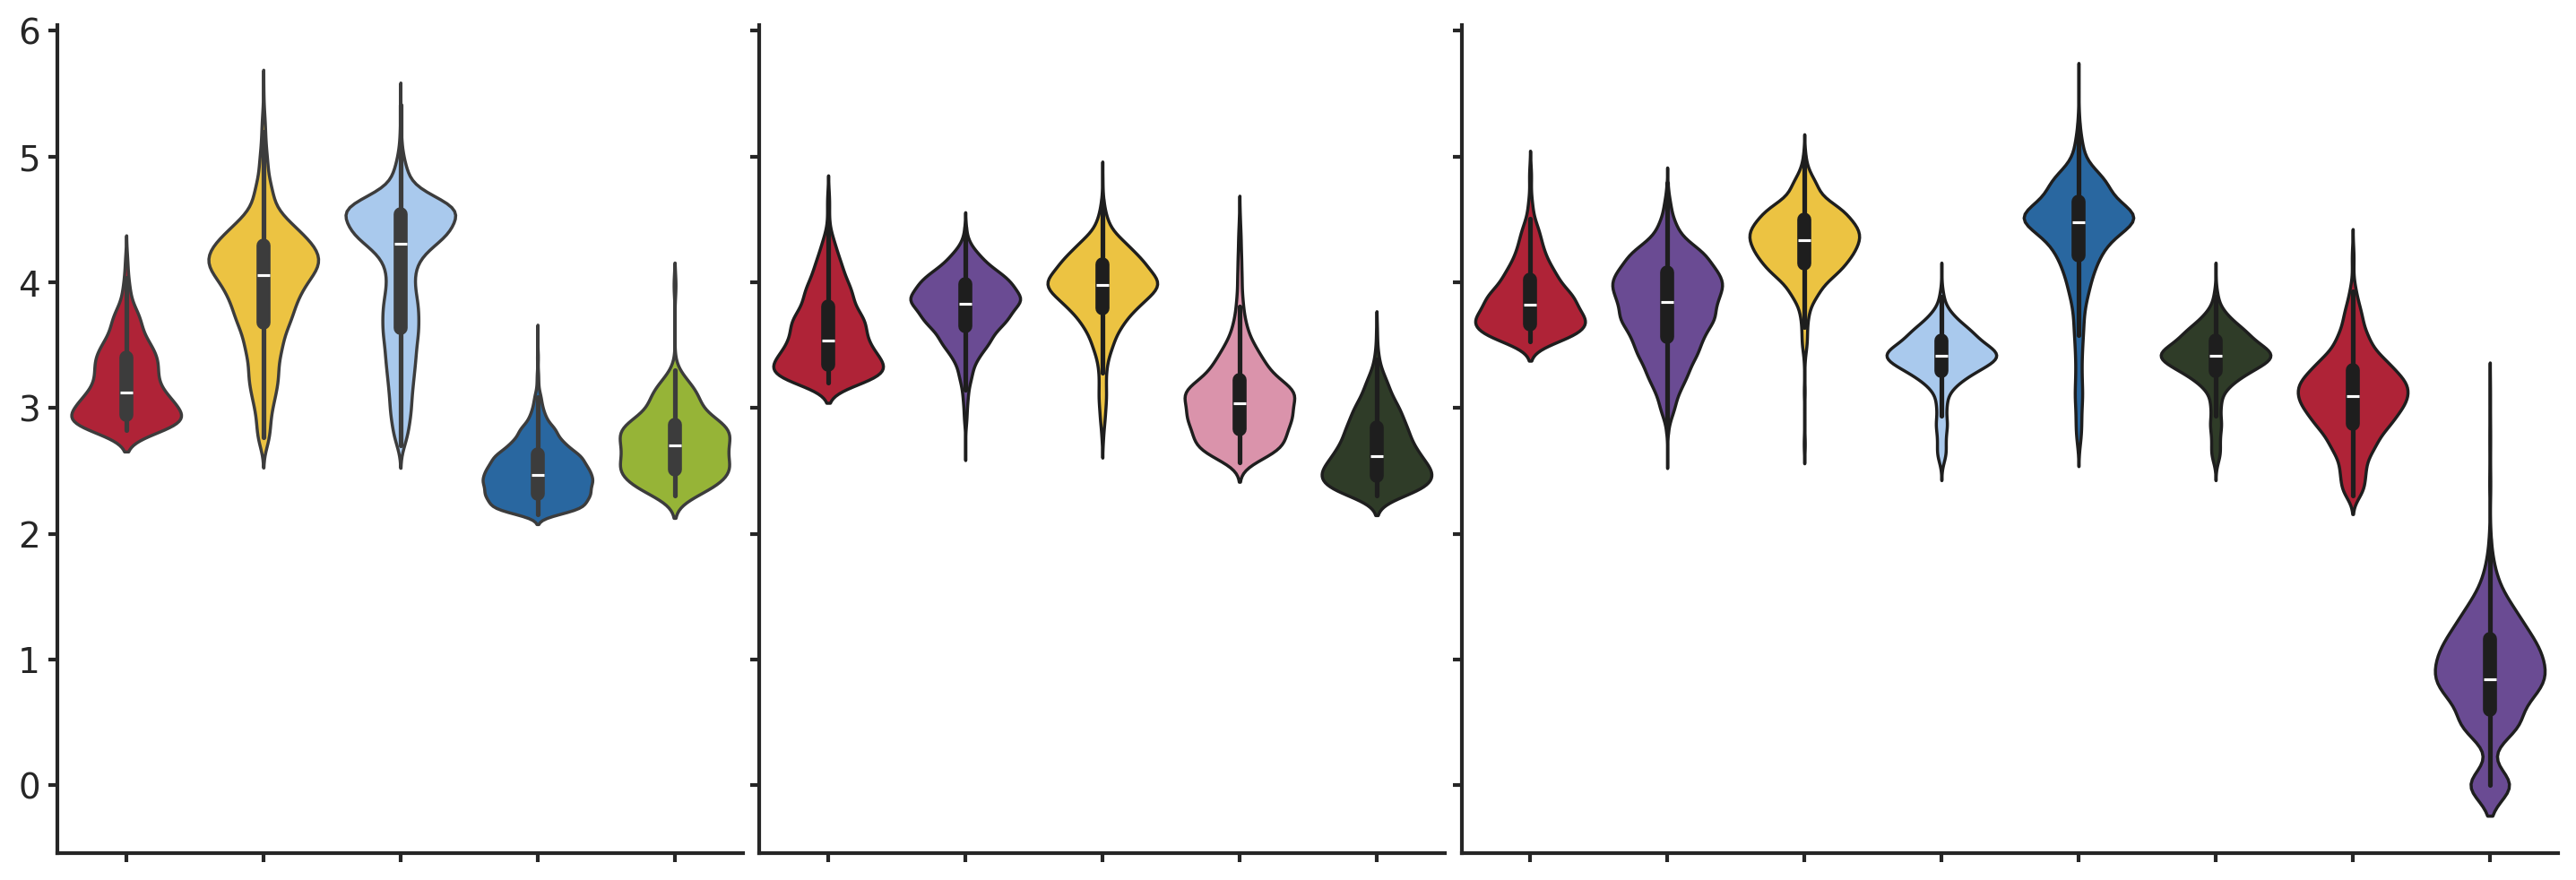

In [8]:
fig, ax = plt.subplots(figsize=(18,6), ncols=3, gridspec_kw={'width_ratios' : [5,5,8], 'wspace' : 0.02}, sharey=True)

sns.violinplot(data = cell_lines.query('Modality == "atac" & Cell_line == "K562"'), 
               x='Method', y='logC', ax=ax[0], width=0.8, saturation=1, scale='width',
               palette=sns.color_palette(['#af2337', '#ecc342', '#a9c9ed', '#2967a0', '#96b437']),
               order=['DUET-seq', 'ISSAAC-seq (Droplet)', '10x Multiome', 'SHARE-seq', 'SNARE-seq'])

sns.violinplot(data = cell_lines.query('Modality == "atac" & Cell_line == "HEK293T"'), 
               x='Method', y='logC', ax=ax[1], width=0.8, saturation=1, scale='width',
               palette=sns.color_palette(['#af2337', '#6a4b93', '#ecc342', '#da93ab', '#2f3c28']),
               order=['DUET-seq', 'HT-scCAT-seq', 'ISSAAC-seq (Droplet)', 'Paired-seq', 'sci-CAR-seq'])

sns.violinplot(data = cell_lines.query('Modality == "atac" & Cell_line == "NIH3T3"'), 
               x='Method', y='logC', ax=ax[2], width=0.8, saturation=1, scale='width',
               palette=sns.color_palette(['#af2337', '#6a4b93', '#ecc342', '#a9c9ed', '#2967a0', '#2f3c28']),
               order=['DUET-seq', 'SUM-seq', 'HT-scCAT-seq', 'ISSAAC-seq (Droplet)', '10x Multiome', 'SNARE-seq2', 'SHARE-seq', 'sci-CAR-seq'])


for a in ax:
    a.set_ylabel('')
    a.set_xticklabels([])
    a.set_xlabel('')
    a.legend('', frameon=False)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.spines['left'].set_linewidth(1.5)
    a.spines['bottom'].set_linewidth(1.5)

save_path = os.path.join(output_dir, 'ATAC_comparison_cell_lines.pdf')
plt.savefig(save_path, bbox_inches='tight', transparent=True)
print(f"Saved: {save_path}")
plt.show()

In [9]:
ax[0].get_ylim()

(-0.5419903797867182, 6.044199072097644)

/tmp/ipykernel_2383318/1538036406.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = cell_lines.query('Modality == "rna" & Cell_line == "K562"'),
/tmp/ipykernel_2383318/1538036406.py:3: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data = cell_lines.query('Modality == "rna" & Cell_line == "K562"'),
/tmp/ipykernel_2383318/1538036406.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = cell_lines.query('Modality == "rna" & Cell_line == "HEK293T"'),
/tmp/ipykernel_2383318/1538036406.py:8: FutureWarning: 

The `scale` parameter has been renamed and will be removed in 

Saved: /s1/chengd/project/multiome/02_cellline/qc_figures/04_technical_qc_comparisons/RNA_comparison_cell_line_UMIs.pdf


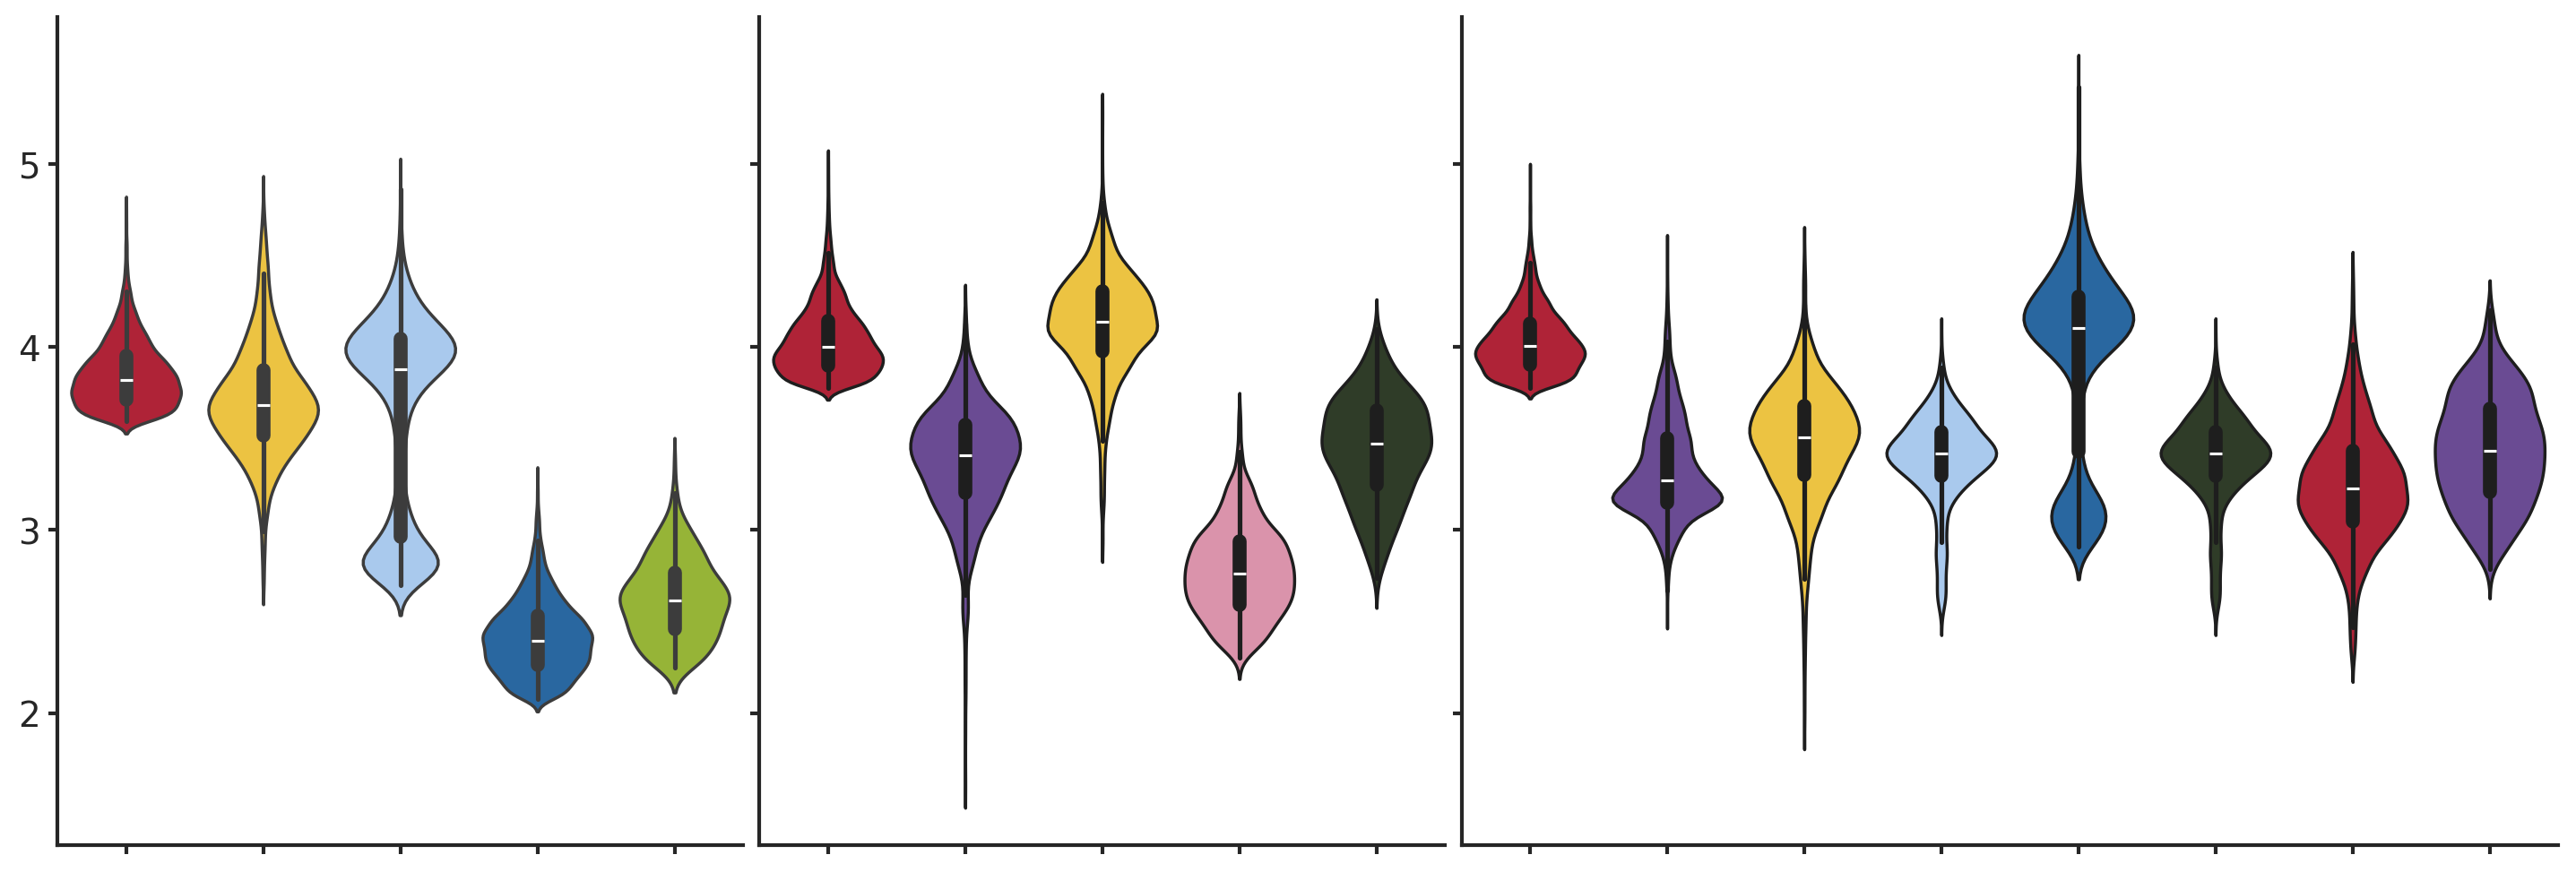

In [10]:
fig, ax = plt.subplots(figsize=(18,6), ncols=3, gridspec_kw={'width_ratios' : [5,5,8], 'wspace' : 0.02}, sharey=True)

sns.violinplot(data = cell_lines.query('Modality == "rna" & Cell_line == "K562"'), 
               x='Method', y='logC', ax=ax[0], width=0.8, saturation=1, scale='width',
               palette=sns.color_palette(['#af2337', '#ecc342', '#a9c9ed', '#2967a0', '#96b437']),
               order=['DUET-seq', 'ISSAAC-seq (Droplet)', '10x Multiome', 'SHARE-seq', 'SNARE-seq'])

sns.violinplot(data = cell_lines.query('Modality == "rna" & Cell_line == "HEK293T"'), 
               x='Method', y='logC', ax=ax[1], width=0.8, saturation=1, scale='width',
               palette=sns.color_palette(['#af2337', '#6a4b93', '#ecc342', '#da93ab', '#2f3c28']),
               order=['DUET-seq', 'HT-scCAT-seq', 'ISSAAC-seq (Droplet)', 'Paired-seq', 'sci-CAR-seq'])

sns.violinplot(data = cell_lines.query('Modality == "rna" & Cell_line == "NIH3T3"'), 
               x='Method', y='logC', ax=ax[2], width=0.8, saturation=1, scale='width',
               palette=sns.color_palette(['#af2337', '#6a4b93', '#ecc342', '#a9c9ed', '#2967a0', '#2f3c28']),
               order=['DUET-seq', 'SUM-seq', 'HT-scCAT-seq', 'ISSAAC-seq (Droplet)', '10x Multiome', 'SNARE-seq2', 'SHARE-seq', 'sci-CAR-seq'])


for a in ax:
    a.set_ylabel('')
    a.set_xticklabels([])
    a.set_xlabel('')
    a.legend('', frameon=False)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.spines['left'].set_linewidth(1.5)
    a.spines['bottom'].set_linewidth(1.5)
    
save_path = os.path.join(output_dir, 'RNA_comparison_cell_line_UMIs.pdf')
plt.savefig(save_path, bbox_inches='tight', transparent=True)
print(f"Saved: {save_path}")
plt.show()

/tmp/ipykernel_2383318/2352965394.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = cell_lines.query('Modality == "rna" & Cell_line == "K562"'),
/tmp/ipykernel_2383318/2352965394.py:3: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data = cell_lines.query('Modality == "rna" & Cell_line == "K562"'),
/tmp/ipykernel_2383318/2352965394.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = cell_lines.query('Modality == "rna" & Cell_line == "HEK293T"'),
/tmp/ipykernel_2383318/2352965394.py:8: FutureWarning: 

The `scale` parameter has been renamed and will be removed in 

Saved: /s1/chengd/project/multiome/02_cellline/qc_figures/04_technical_qc_comparisons/RNA_comparison_cell_line_genes.pdf


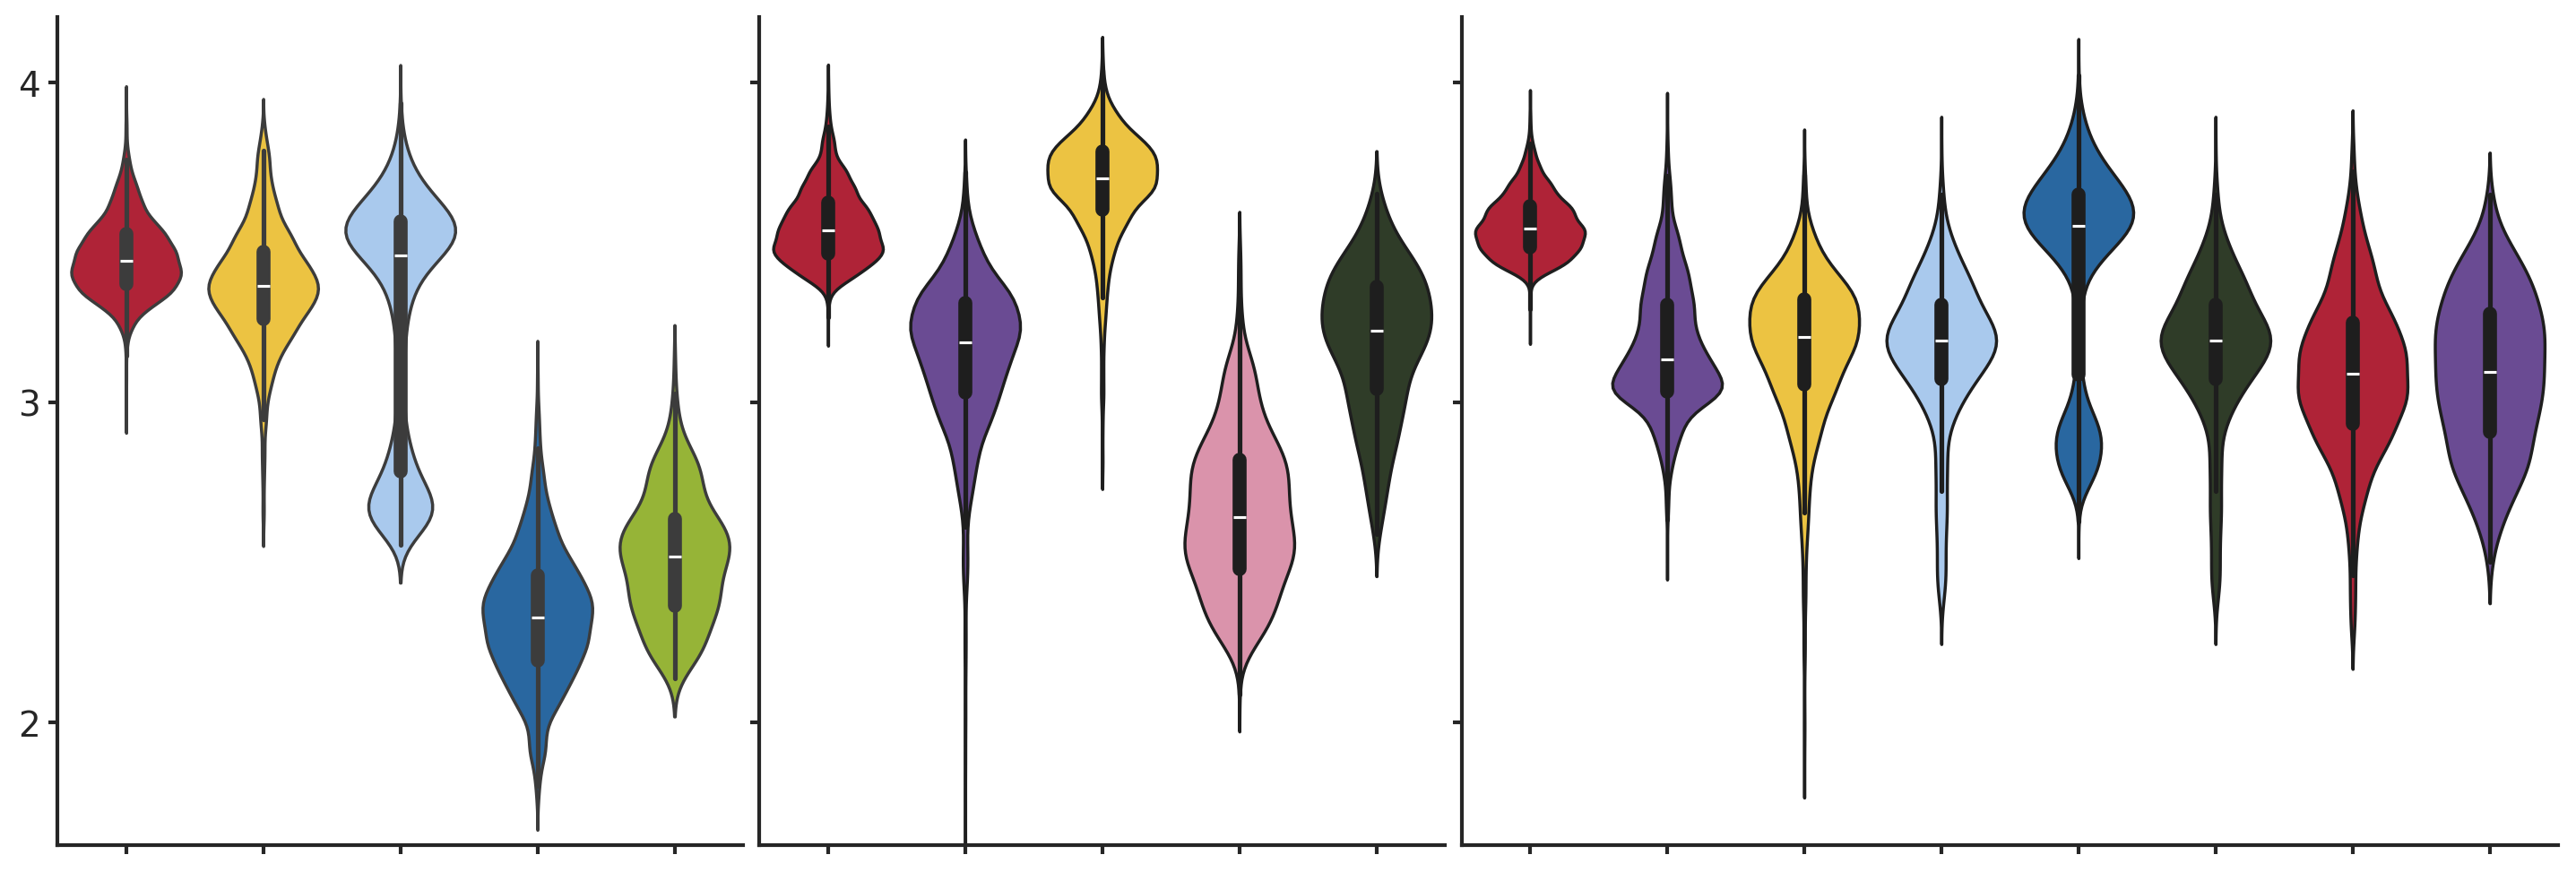

In [11]:
fig, ax = plt.subplots(figsize=(18,6), ncols=3, gridspec_kw={'width_ratios' : [5,5,8], 'wspace' : 0.02}, sharey=True)

sns.violinplot(data = cell_lines.query('Modality == "rna" & Cell_line == "K562"'),
            x='Method', y='logF', ax=ax[0], width=0.8, saturation=1, scale='width',
            palette=sns.color_palette(['#af2337', '#ecc342', '#a9c9ed', '#2967a0', '#96b437']),
            order=['DUET-seq', 'ISSAAC-seq (Droplet)', '10x Multiome', 'SHARE-seq', 'SNARE-seq'])

sns.violinplot(data = cell_lines.query('Modality == "rna" & Cell_line == "HEK293T"'), 
            x='Method', y='logF', ax=ax[1], width=0.8, saturation=1, scale='width',
            palette=sns.color_palette(['#af2337', '#6a4b93', '#ecc342', '#da93ab', '#2f3c28']),
            order=['DUET-seq', 'HT-scCAT-seq', 'ISSAAC-seq (Droplet)', 'Paired-seq', 'sci-CAR-seq'])

sns.violinplot(data = cell_lines.query('Modality == "rna" & Cell_line == "NIH3T3"'), 
            x='Method', y='logF', ax=ax[2], width=0.8, saturation=1, scale='width',
            palette=sns.color_palette(['#af2337', '#6a4b93', '#ecc342', '#a9c9ed', '#2967a0', '#2f3c28']),
            order=['DUET-seq', 'SUM-seq', 'HT-scCAT-seq', 'ISSAAC-seq (Droplet)', '10x Multiome', 'SNARE-seq2', 'SHARE-seq', 'sci-CAR-seq'])


for a in ax:
    a.set_ylabel('')
    a.set_xticklabels([])
    a.set_xlabel('')
    a.legend('', frameon=False)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.spines['left'].set_linewidth(1.5)
    a.spines['bottom'].set_linewidth(1.5)

ax[0].set_ylim(1.6146865586264567, 4.204244984949719)
ax[0].set_yticks([2,3,4])

save_path = os.path.join(output_dir, 'RNA_comparison_cell_line_genes.pdf')
plt.savefig(save_path, bbox_inches='tight', transparent=True)
print(f"Saved: {save_path}")
plt.show()

In [12]:
ax[0].get_ylim()

(1.6146865586264567, 4.204244984949719)

In [13]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
from collections import Counter
import matplotlib.pyplot as plt

kelly = ['#af2337', '#ecc342', '#2967a0', '#2f3c28', '#96b437',
         '#da93ab', '#e58932', '#80598f', '#7e331f', '#3b855a',
         '#c0b286', '#a9c9ed', '#ec977f', '#848482', '#604628',
         '#d26034', '#a64c6b', '#dbd245', '#eba83b', '#5d5092',
         '#222222', '#f2f3f4', '#6a4b93']

mpl.rcParams['axes.prop_cycle'] = plt.cycler(color=kelly)
mpl.rcParams['axes.titlesize'] = 19
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 13
mpl.rcParams['legend.markerscale'] = 2
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['figure.dpi'] = 100

sns.set_style('ticks')

In [14]:
brain_metrics = [
    ['duet-seq (N1)'            , 'ATAC', '/s1/chengd/project/multiome/01_preprocessing/duet-seq/whole_brain_N1/atac/metrics.csv'],
    ['duet-seq (N1)'            , 'RNA' , '/s1/chengd/project/multiome/01_preprocessing/duet-seq/whole_brain_N1/rna/metrics.csv'],
    ['duet-seq (N2)'            , 'ATAC', '/s1/chengd/project/multiome/01_preprocessing/duet-seq/whole_brain_N2/atac/metrics.csv'],
    ['duet-seq (N2)'            , 'RNA' , '/s1/chengd/project/multiome/01_preprocessing/duet-seq/whole_brain_N2/rna/metrics.csv'],
    ['ISSAAC-seq (Droplet) rep1', 'ATAC', '/s1/chengd/project/multiome/01_preprocessing/issaac-seq/mCortex_Droplet_rep1/atac/metrics.csv'],
    ['ISSAAC-seq (Droplet) rep1', 'RNA' , '/s1/chengd/project/multiome/01_preprocessing/issaac-seq/mCortex_Droplet_rep1/rna/metrics.csv'],
    ['10x Multiome (Chromium_Nuclei)'             , 'ATAC', '/s1/chengd/project/multiome/01_preprocessing/10x_multiome/Mouse_Brain_Chromium_Nuclei/atac/metrics.csv'],
    ['10x Multiome (Chromium_Nuclei)'             , 'RNA' , '/s1/chengd/project/multiome/01_preprocessing/10x_multiome/Mouse_Brain_Chromium_Nuclei/rna/metrics.csv'],
    ['10x Multiome (CT_sorted)'             , 'ATAC', '/s1/chengd/project/multiome/01_preprocessing/10x_multiome/Mouse_Brain_CT_sorted/atac/metrics.csv'],
    ['10x Multiome (CT_sorted)'             , 'RNA' , '/s1/chengd/project/multiome/01_preprocessing/10x_multiome/Mouse_Brain_CT_sorted/rna/metrics.csv'],
    ['10x Multiome (CT_unsorted)'             , 'ATAC', '/s1/chengd/project/multiome/01_preprocessing/10x_multiome/Mouse_Brain_CT_unsorted/atac/metrics.csv'],
    ['10x Multiome (CT_unsorted)'             , 'RNA' , '/s1/chengd/project/multiome/01_preprocessing/10x_multiome/Mouse_Brain_CT_unsorted/rna/metrics.csv'],
    ['10x Multiome (SaltyEZ)'             , 'ATAC', '/s1/chengd/project/multiome/01_preprocessing/10x_multiome/Mouse_Brain_SaltyEZ/atac/metrics.csv'],
    ['10x Multiome (SaltyEZ)'             , 'RNA' , '/s1/chengd/project/multiome/01_preprocessing/10x_multiome/Mouse_Brain_SaltyEZ/rna/metrics.csv'],
    ['SHARE-seq (Whole_Brain)'                , 'ATAC', '/s1/chengd/project/multiome/01_preprocessing/share-seq/mouse_brain/atac/metrics.csv'],
    ['SHARE-seq (Whole_Brain)'                , 'RNA' , '/s1/chengd/project/multiome/01_preprocessing/share-seq/mouse_brain/rna/metrics.csv'],
    ['Paired-seq (Adult_cortex)'   , 'ATAC', '/s1/chengd/project/multiome/01_preprocessing/paired-seq/adult_cortex/atac/metrics.csv'],
    ['Paired-seq (Adult_cortex)'   , 'RNA' , '/s1/chengd/project/multiome/01_preprocessing/paired-seq/adult_cortex/rna/metrics.csv'],
    ['SNARE-seq (Adult_cortex)'          , 'ATAC', '/s1/chengd/project/multiome/01_preprocessing/snare-seq/adult_mouse_brain_cortex/atac/metrics.csv'],
    ['SNARE-seq (Adult_cortex)'          , 'RNA' , '/s1/chengd/project/multiome/01_preprocessing/snare-seq/adult_mouse_brain_cortex/rna/metrics.csv']
]

In [15]:
dfs = []

for t, m, q in brain_metrics:
    tmp = pd.read_csv(q)
    tmp['Method'] = t
    tmp['Modality'] = m
    dfs.append(tmp)

brain_info = pd.concat(dfs, ignore_index = True)
brain_info.head()

,cell,nCounts,nFeatures,Method,Modality
0,AAGAACTGCTTTGCTC,3654,2036,duet-seq (N1),ATAC
1,AAGAAGTGTGTTGTGG,4601,2565,duet-seq (N1),ATAC
2,AAGACAGGTTGCTCCT,2627,1522,duet-seq (N1),ATAC
3,AAGACAGGTTTCGTGG,7191,3869,duet-seq (N1),ATAC
4,AAGACATGGCTGTACT,11553,6020,duet-seq (N1),ATAC


In [16]:
brain_info['logC'] = np.log10(brain_info['nCounts'])
brain_info['logF'] = np.log10(brain_info['nFeatures'])

/tmp/ipykernel_2383318/2418859429.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = brain_info.query('Modality == "ATAC"'),
/tmp/ipykernel_2383318/2418859429.py:6: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data = brain_info.query('Modality == "ATAC"'),
/tmp/ipykernel_2383318/2418859429.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = brain_info.query('Modality == "RNA"'),
/tmp/ipykernel_2383318/2418859429.py:12: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.v

Saved: /s1/chengd/project/multiome/02_cellline/qc_figures/04_technical_qc_comparisons/mCortex_comparisons_all.pdf


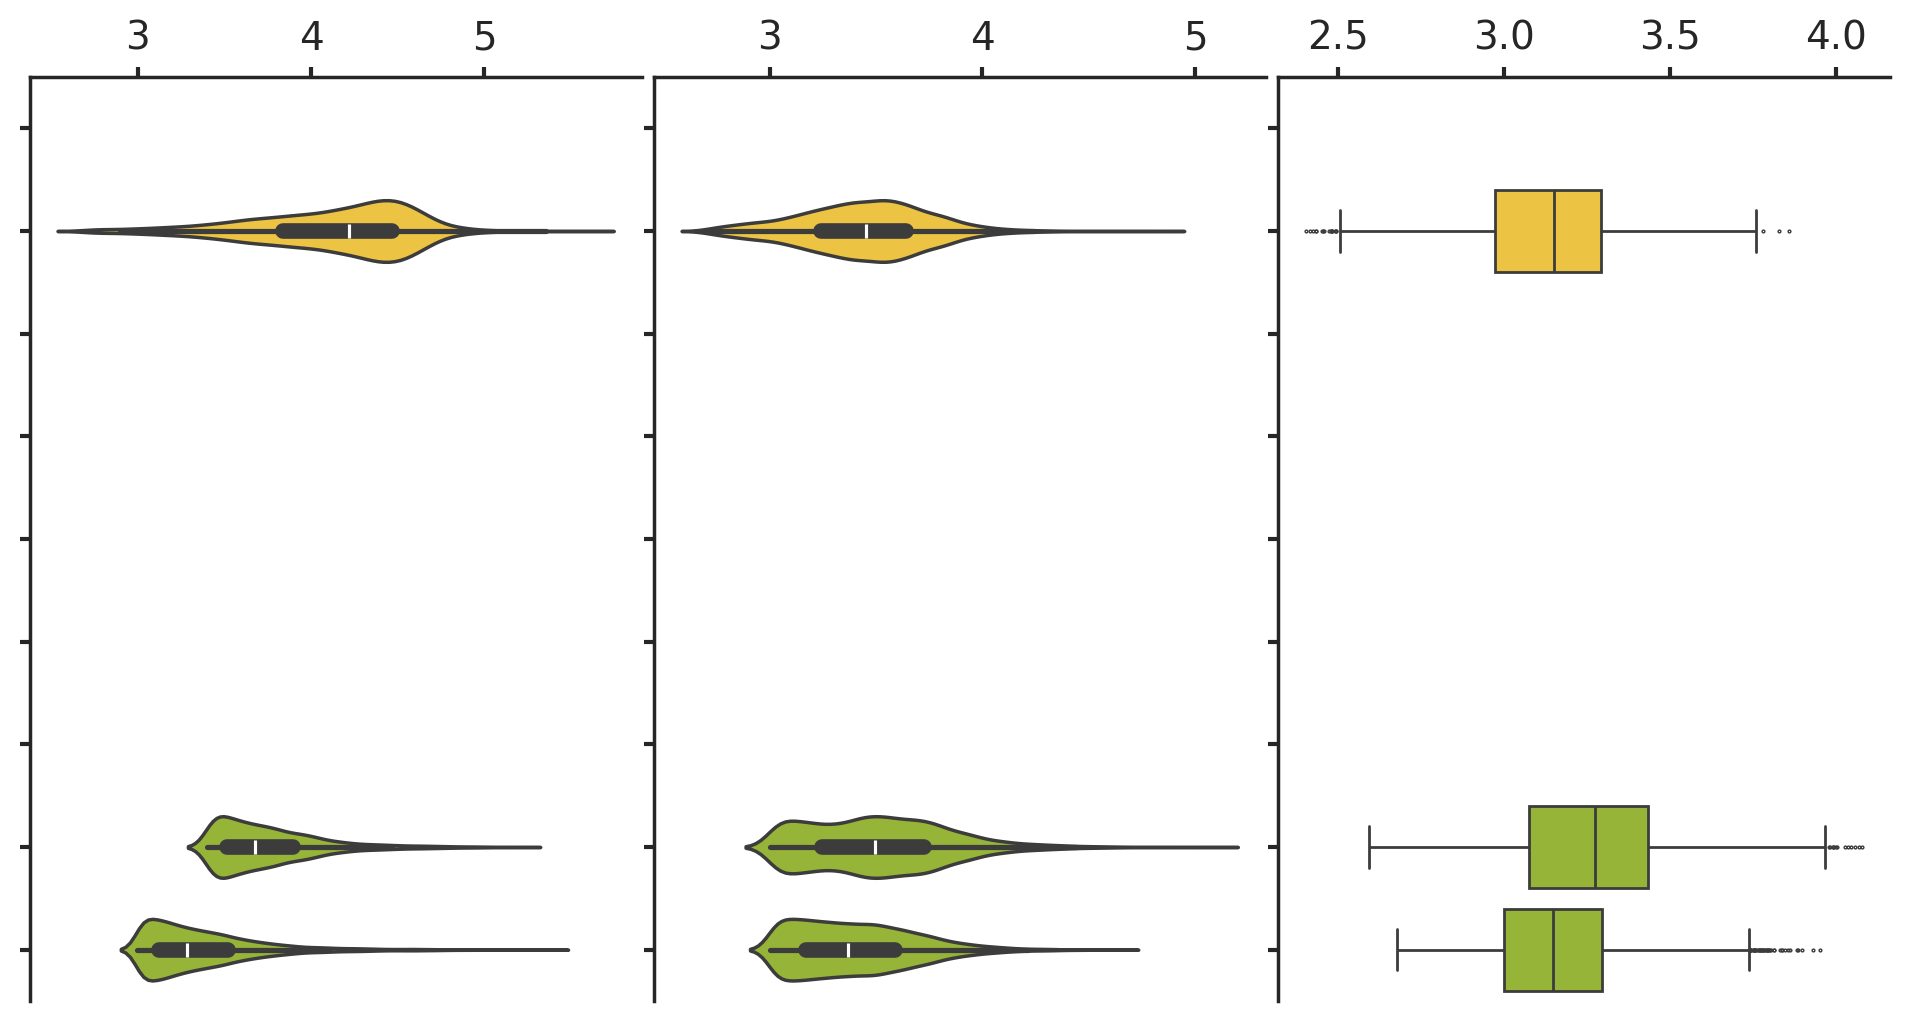

In [17]:
mpl.rcParams['xtick.bottom'] = plt.rcParams['xtick.labelbottom'] = False
mpl.rcParams['xtick.top'] = plt.rcParams['xtick.labeltop'] = True

fig, ax = plt.subplots(figsize=(12,6), ncols=3, gridspec_kw={'width_ratios' : [1,1,1], 'wspace' : 0.02}, sharey=True)

sns.violinplot(data = brain_info.query('Modality == "ATAC"'),
               x='logC', y='Method', ax=ax[0], width=0.6, saturation=1, scale='width', orient='h',
               order=['ISSAAC-seq (FACS)', 'ISSAAC-seq (Droplet) rep1', 'ISSAAC-seq (Droplet) rep2', '10x Multiome',
                      'SHARE-seq', 'Paired-seq (Adult_CTX)', 'Paired-seq (FB)', 'duet-seq (N1)', 'duet-seq (N2)'],
               palette=sns.color_palette(['#af2337', '#ecc342', '#ecc342', '#a9c9ed', '#2967a0', '#da93ab', '#da93ab', '#96b437', '#96b437']))

sns.violinplot(data = brain_info.query('Modality == "RNA"'),
               x='logC', y='Method', ax=ax[1], width=0.6, saturation=1, scale='width', orient='h',
               order=['ISSAAC-seq (FACS)', 'ISSAAC-seq (Droplet) rep1', 'ISSAAC-seq (Droplet) rep2', '10x Multiome',
                      'SHARE-seq', 'Paired-seq (Adult_CTX)', 'Paired-seq (FB)', 'duet-seq (N1)', 'duet-seq (N2)'],
               palette=sns.color_palette(['#af2337', '#ecc342', '#ecc342', '#a9c9ed', '#2967a0', '#da93ab', '#da93ab', '#96b437', '#96b437']))

sns.boxplot(data = brain_info.query('Modality == "RNA"'),
            x='logF', y='Method', ax=ax[2], saturation=1, fliersize=0.5, orient='h',
            order=['ISSAAC-seq (FACS)', 'ISSAAC-seq (Droplet) rep1', 'ISSAAC-seq (Droplet) rep2', '10x Multiome',
                      'SHARE-seq', 'Paired-seq (Adult_CTX)', 'Paired-seq (FB)', 'duet-seq (N1)', 'duet-seq (N2)'],
               palette=sns.color_palette(['#af2337', '#ecc342', '#ecc342', '#a9c9ed', '#2967a0', '#da93ab', '#da93ab', '#96b437', '#96b437']))

for a in ax:
    a.set_ylabel('')
    a.set_yticklabels([])
    a.set_xlabel('')
    a.spines['bottom'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.spines['left'].set_linewidth(1.25)
    a.spines['top'].set_linewidth(1.25)

save_path = os.path.join(output_dir, 'mCortex_comparisons_all.pdf')
plt.savefig(save_path, bbox_inches='tight', transparent=True)
print(f"Saved: {save_path}")
plt.show()

In [18]:
brain_info.groupby(['Method', 'Modality']).median()

/tmp/ipykernel_2383318/412153216.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  brain_info.groupby(['Method', 'Modality']).median()


nCounts  nFeatures      logC  \
Method                         Modality                                 
10x Multiome (CT_sorted)       ATAC       6033.5     2768.5  3.780568   
                               RNA        2854.5     1347.0  3.455530   
10x Multiome (CT_unsorted)     ATAC       3528.0     1783.0  3.547529   
                               RNA        6546.0     2856.0  3.815976   
10x Multiome (Chromium_Nuclei) ATAC       5240.0     2573.0  3.719331   
                               RNA        6583.0     2860.0  3.818424   
10x Multiome (SaltyEZ)         ATAC       3669.0     1816.5  3.564548   
                               RNA        5240.0     2545.0  3.719331   
ISSAAC-seq (Droplet) rep1      ATAC      16619.5     8138.0  4.220618   
                               RNA        2848.5     1410.0  3.454616   
Paired-seq (Adult_cortex)      ATAC       1246.5     1200.0  3.095692   
                               RNA         448.0      313.0  2.651278   
SHARE-seq (Whole_Brain)        ATAC        969.0      956.0  2.986324   
                               RNA        3469.0     1655.0  3.540204   
SNARE-seq (Adult_cortex)       ATAC       2324.0     2197.0  3.366236   
                               RNA         433.0      340.0  2.636488   
duet-seq (N1)                  ATAC       4736.0     2609.5  3.675412   
                               RNA        3143.0     1881.0  3.497344   
duet-seq (N2)                  ATAC       1921.0     1063.0  3.283527   
                               RNA        2328.0     1407.5  3.366983   

                                             logF  
Method                         Modality            
10x Multiome (CT_sorted)       ATAC      3.442244  
                               RNA       3.129368  
10x Multiome (CT_unsorted)     ATAC      3.251151  
                               RNA       3.455758  
10x Multiome (Chromium_Nuclei) ATAC      3.410440  
                               RNA       3.456366  
10x Multiome (SaltyEZ)         ATAC      3.259235  
                               RNA       3.405688  
ISSAAC-seq (Droplet) rep1      ATAC      3.910518  
                               RNA       3.149219  
Paired-seq (Adult_cortex)      ATAC      3.079181  
                               RNA       2.495544  
SHARE-seq (Whole_Brain)        ATAC      2.980458  
                               RNA       3.218798  
SNARE-seq (Adult_cortex)       ATAC      3.341830  
                               RNA       2.531479  
duet-seq (N1)                  ATAC      3.416557  
                               RNA       3.274389  
duet-seq (N2)                  ATAC      3.026533  
                               RNA       3.148448